# Taller 1 - Punto 1: Regresión lineal
## Predicción de la productividad del cultivo de arroz (paddy)

**Pontificia Universidad Javeriana - Maestría en Inteligencia Artificial - Aprendizaje de máquina**

Este notebook desarrolla el **Punto 1** del Taller 1: un modelo de regresión lineal, implementado desde cero utilizando únicamente **NumPy** (todos los cálculos vectorizados), que predice la **productividad** del cultivo de arroz, definida como:

$$\text{Productividad} = \frac{\text{Paddy yield (in Kg)}}{\text{Hectares}}$$

Se utiliza el dataset [Paddy Dataset](https://archive.ics.uci.edu/dataset/1186/paddy+dataset) de UCI Machine Learning Repository.


## 1. Setup

Importamos únicamente las librerías permitidas por el enunciado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)

## 2. Carga de datos

El dataset se descarga directamente del repositorio de UCI (paquete zip con un único CSV, `paddydataset.csv`) y se carga con pandas.

In [105]:
url = "https://archive.ics.uci.edu/static/public/1186/paddy+dataset.zip"
df = pd.read_csv(url, compression="zip")
df.columns = [c.strip() for c in df.columns]
df.shape

(2789, 45)

In [106]:
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   str    
 2   Variety                             2789 non-null   str    
 3   Soil Types                          2789 non-null   str    
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   str    
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 non-null   fl

No hay valores nulos y las columnas mezclan variables numéricas con variables categóricas (Agriblock, Variety, Soil Types, Nursery, Wind Direction_*).

## 3. Exploración de datos

### 3.1 Creación de la variable objetivo

La variable **productividad** se construye dividiendo el rendimiento (`Paddy yield(in Kg)`) entre las hectáreas cultivadas (`Hectares`).

**IMPORTANTEE:** dado que la variable objetivo se calcula directamente a partir de `Paddy yield(in Kg)`, esta columna se elimina del conjunto de variables predictoras. De lo contrario, el modelo aprendería la etiqueta reconstruyendo el target con casi cero error en lugar de hacer una predicción genuina previa a la cosecha. `Hectares` sí se conserva porque es una decisión agronómica a priori.

In [108]:
df["Productividad"] = df["Paddy yield(in Kg)"] / df["Hectares"]
df = df.drop(columns=["Paddy yield(in Kg)"])
df["Productividad"].describe()

count    2789.000000
mean     5990.531015
std       283.243564
min      5410.000000
25%      5836.000000
50%      5964.000000
75%      6227.000000
max      6469.000000
Name: Productividad, dtype: float64

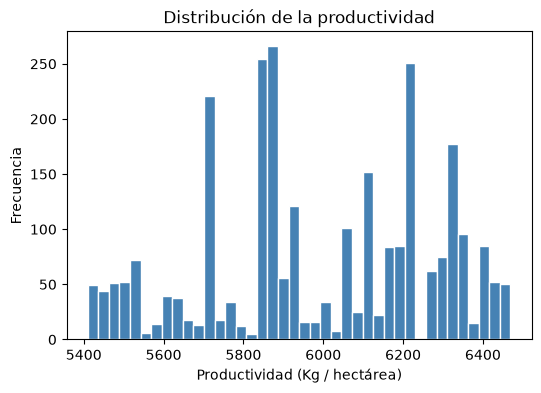

In [109]:
plt.figure(figsize=(6,4))
plt.hist(df["Productividad"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Productividad (Kg / hectárea)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la productividad")
plt.show()

### 3.2 Variables categóricas y su distribución

In [110]:
cat_cols = ["Agriblock", "Variety", "Soil Types", "Nursery"]
for c in cat_cols:
    print(df[c].value_counts(), "\n")

Agriblock
Sankarapuram    605
Kurinjipadi     486
Cuddalore       450
Panruti         425
Kallakurichi    413
Chinnasalem     410
Name: count, dtype: int64 

Variety
ponmani        1061
delux ponni     996
CO_43           732
Name: count, dtype: int64 

Soil Types
clay        1521
alluvial    1268
Name: count, dtype: int64 

Nursery
dry    1540
wet    1249
Name: count, dtype: int64 



### 3.3 Correlación de variables numéricas con la productividad

Para orientar la selección de variables y evitar multicolinealidad severa, se calcula la correlación entre cada variable numérica y la productividad (empleando las funciones de exploración de Pandas permitidas).

In [111]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop("Productividad")

correlaciones = df[numeric_cols.tolist() + ["Productividad"]].corr()["Productividad"].drop("Productividad")
correlaciones = correlaciones.sort_values(key=np.abs, ascending=False)
correlaciones

Hectares                              0.609589
LP_nurseryarea(in Tonnes)             0.609589
Weed28D_thiobencarb                   0.609589
Micronutrients_70Days                 0.609589
Nursery area (Cents)                  0.609589
DAP_20days                            0.609589
Urea_40Days                           0.609589
Seedrate(in Kg)                       0.609589
LP_Mainfield(in Tonnes)               0.609589
Pest_60Day(in ml)                     0.609589
Potassh_50Days                        0.609589
Trash(in bundles)                     0.564399
Inst Wind Speed_D1_D30(in Knots)      0.033125
Inst Wind Speed_D61_D90(in Knots)     0.024545
Max temp_D61_D90                      0.024203
Min temp_D61_D90                      0.023674
Min temp_D1_D30                       0.023484
Min temp_D31_D60                      0.017799
Max temp_D1_D30                      -0.015986
Relative Humidity_D1_D30             -0.014847
Relative Humidity_D61_D90            -0.014560
30DRain( in m

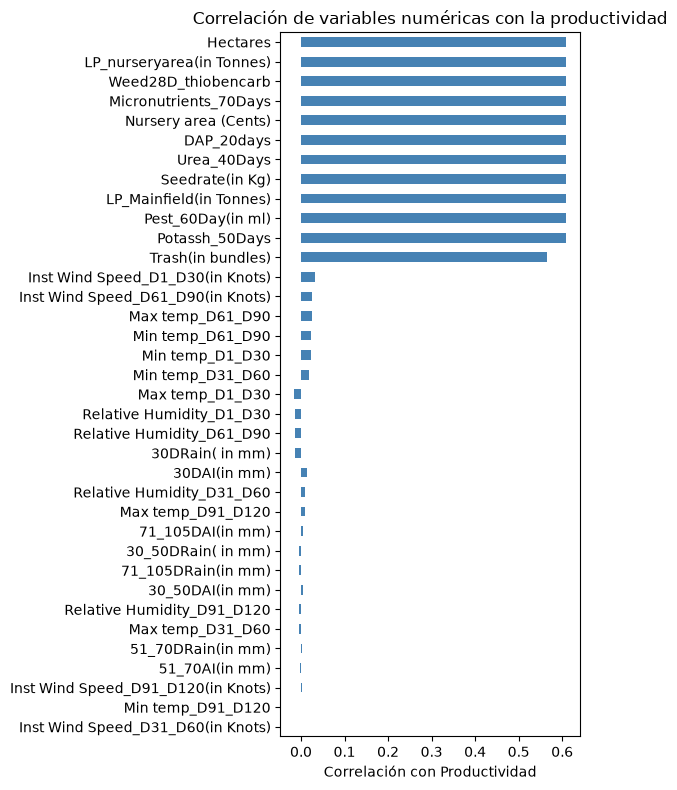

In [112]:
plt.figure(figsize=(6,8))
correlaciones.plot(kind="barh", color="steelblue")
plt.xlabel("Correlación con Productividad")
plt.gca().invert_yaxis()
plt.title("Correlación de variables numéricas con la productividad")
plt.tight_layout()
plt.show()

Un grupo de variables agronómicas (`Seedrate`, `LP_Mainfield`, `Nursery area`, `LP_nurseryarea`, `DAP_20days`, `Weed28D_thiobencarb`, `Urea_40Days`, `Potassh_50Days`, `Micronutrients_70Days`, `Pest_60Day`) muestra exactamente la misma correlación (~0.61) con la productividad. Esto sugiere colinealidad perfecta.

### 3.4 Detección de variables redundantes y de posible fuga de información

Como se vio en clase, es importante descartar variables independientes que tengan alta correlación entre ellas. Se verifica si el grupo detectado arriba son variables dependientes deterministas de `Hectares` (dosis agronómicas por hectárea).

In [113]:
dosage_like_cols = [
    "Seedrate(in Kg)", "LP_Mainfield(in Tonnes)", "Nursery area (Cents)", "LP_nurseryarea(in Tonnes)",
    "DAP_20days", "Weed28D_thiobencarb", "Urea_40Days", "Potassh_50Days",
    "Micronutrients_70Days", "Pest_60Day(in ml)"
]
ratio_stats = pd.DataFrame({
    "correlacion_con_Hectares": [df[c].astype(float).corr(df["Hectares"].astype(float)) for c in dosage_like_cols],
    "std(variable/Hectares)": [(df[c] / df["Hectares"]).std() for c in dosage_like_cols],
}, index=dosage_like_cols)
ratio_stats

,correlacion_con_Hectares,std(variable/Hectares)
Seedrate(in Kg),1.0,0.000000e+00
LP_Mainfield(in Tonnes),1.0,0.000000e+00
Nursery area (Cents),1.0,0.000000e+00
LP_nurseryarea(in Tonnes),1.0,0.000000e+00
DAP_20days,1.0,0.000000e+00
Weed28D_thiobencarb,1.0,0.000000e+00
Urea_40Days,1.0,2.962803e-15
Potassh_50Days,1.0,3.120933e-15
Micronutrients_70Days,1.0,0.000000e+00
Pest_60Day(in ml),1.0,0.000000e+00


Las 10 variables tienen correlación **1.0** con `Hectares` y una desviación estándar de **0** en su razón `variable / Hectares`. Son **copias redundantes** de `Hectares` bajo otra escala. Por el principio de parsimonia enseñado en clase, se descartan conservando únicamente `Hectares`.

Adicionalmente, se revisa `Trash(in bundles)` (residuos de la cosecha), que no forma parte de este grupo pero muestra una correlación inusualmente alta.

In [114]:
print("Correlación Trash vs Productividad:", df["Trash(in bundles)"].astype(float).corr(df["Productividad"].astype(float)))

# Recreamos temporalmente Paddy yield para verificar
paddy_yield_temp = df["Productividad"] * df["Hectares"]
print("Correlación Trash vs Paddy yield (antes de eliminarlo):", df["Trash(in bundles)"].astype(float).corr(paddy_yield_temp.astype(float)))

Correlación Trash vs Productividad: 0.5643990732584763
Correlación Trash vs Paddy yield (antes de eliminarlo): 0.9575959144365859


`Trash(in bundles)` correlaciona **0.96** con el rendimiento total (`Paddy yield`). Al igual que el arroz cosechado, la paja se mide al final del cultivo. Usarla como predictor sería una fuga de información. Se descarta del modelo.

In [115]:
df = df.drop(columns=dosage_like_cols + ["Trash(in bundles)"])
df.shape

(2789, 34)

### 3.5 Transformación de variables: Variables Dummies

Las variables categóricas (incluyendo la dirección del viento) toman etiquetas discretas. Como se enseñó en clase, se deben transformar a **variables dummy** indicando su presencia (1) o ausencia (0), omitiendo la primera categoría para evitar colinealidad perfecta.

In [116]:
wind_cols = [c for c in df.columns if c.startswith("Wind Direction")]
cat_cols = ["Agriblock", "Variety", "Soil Types", "Nursery"] + wind_cols

# Convertir a string para evitar problemas de tipos mixtos al generar las dummies
for c in cat_cols:
    df[c] = df[c].astype(str)

df_dummies = pd.get_dummies(df[cat_cols], drop_first=True)
df_dummies = df_dummies.astype(float) # Asegurar formato numérico para las operaciones posteriores matriciales

df = df.drop(columns=cat_cols).join(df_dummies)
df.shape

(2789, 53)

## 4. Partición de datos

Siguiendo la estrategia de entrenamiento, se divide el conjunto en:
* **Entrenamiento (70%):** para minimizar la función de pérdida.
* **Validación (15%):** para estimar la capacidad predictiva y seleccionar hiperparámetros.
* **Prueba (15%):** para medir el performance en datos "nunca antes vistos".

In [117]:
train_df = df.sample(frac=0.7, random_state=200)
rest_df = df.drop(train_df.index)
val_df = rest_df.sample(frac=0.5, random_state=200)
test_df = rest_df.drop(val_df.index)

train_df.shape, val_df.shape, test_df.shape

((1952, 53), (418, 53), (419, 53))

## 5. Implementación del modelo (NumPy)

Se implementa un modelo de **regresión lineal múltiple** optimizado mediante **descenso de gradiente**, función de costo Error Cuadrático Medio (MSE) y regularización **Ridge (L2)** opcional (para castigar hipótesis complejas y evitar el sobre-entrenamiento).

Hipótesis: $\hat{y} = X\theta$

Función de costo regularizada:
$$J(\theta) = \frac{1}{2n}\sum_{i=1}^n (x_i^\top\theta - y_i)^2 + \frac{\lambda}{2n}\sum_{j=1}^m \theta_j^2$$

Gradiente (Vectorizado):
$$\nabla J(\theta) = \frac{1}{n}X^\top(X\theta - Y) + \frac{\lambda}{n}\theta $$

*Nota: El término de sesgo $\theta_0$ no se regulariza.*

In [118]:
def add_bias(X):
    """Agrega la columna constante de 1's (término independiente) a la matriz de diseño X."""
    return np.hstack((np.ones((X.shape[0], 1)), X))


def standardize(X, mu=None, sigma=None):
    """Normalización de características. mu/sigma se calculan siempre sobre
    train y se reutilizan sobre validación/test."""
    if mu is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
        sigma = np.where(sigma == 0, 1.0, sigma)
    return (X - mu) / sigma, mu, sigma


def mse_cost(theta, X_c, y, lam=0.0):
    """Función de costo (MSE) incluyendo la penalización L2."""
    n = X_c.shape[0]
    error = X_c @ theta - y
    reg = (lam / (2 * n)) * np.sum(theta[1:] ** 2)
    return (1 / (2 * n)) * np.sum(error ** 2) + reg


def fit_model(X_c, y, alpha, epochs, lam=0.0):
    """Descenso de gradiente iterativo vectorizado."""
    n, m = X_c.shape
    theta = np.zeros((m, 1))
    hist = []
    for i in range(epochs):
        grad = (X_c.T @ (X_c @ theta - y)) / n
        reg_grad = (lam / n) * theta
        reg_grad[0, 0] = 0.0 # No penalizamos el sesgo theta_0
        theta = theta - alpha * (grad + reg_grad)
        if i % max(1, epochs // 50) == 0:
            hist.append(mse_cost(theta, X_c, y, lam))
    return theta, hist


def rmse(theta, X_c, y):
    """Cálculo de la Raíz del Error Cuadrático Medio."""
    error = X_c @ theta - y
    return np.sqrt(np.mean(error ** 2))

### 5.1 Verificación de la implementación

Verificamos que el descenso de gradiente minimiza la función de costo de forma progresiva en un caso de regresión lineal simple (utilizando solo la variable `Hectares`).

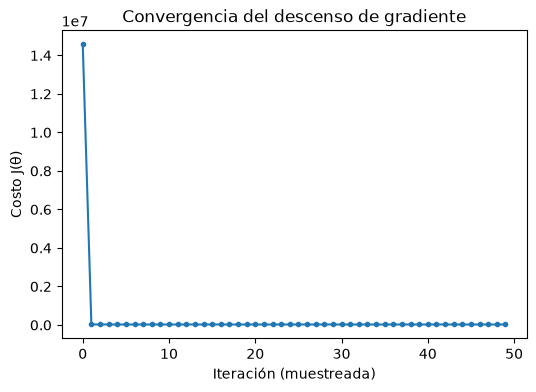

¿Costo estrictamente no creciente? True
theta final: [5989.13985656  171.73899957]


In [119]:
X_check = train_df[["Hectares"]].values.astype(float)
y_check = train_df[["Productividad"]].values.astype(float)
X_check_s, mu_c, sigma_c = standardize(X_check)
X_check_c = add_bias(X_check_s)

theta_check, hist_check = fit_model(X_check_c, y_check, alpha=0.1, epochs=2000, lam=0.0)

plt.figure(figsize=(6,4))
plt.plot(hist_check, marker="o", markersize=3)
plt.xlabel("Iteración (muestreada)")
plt.ylabel("Costo J(θ)")
plt.title("Convergencia del descenso de gradiente")
plt.show()

print("¿Costo estrictamente no creciente?", all(np.diff(hist_check) <= 1e-8))
print("theta final:", theta_check.ravel())

## 6. Experimentación: Selección de variables e hipótesis

Evaluaremos distintas hipótesis empleando el conjunto de entrenamiento para minimizar el error, y el de validación para estimar su capacidad predictiva mediante el RMSE:

* **Modelo A:** Regresión múltiple solo con variables numéricas originales.
* **Modelo B:** Modelo A + inclusión de todas las variables categóricas representadas por dummies.
* **Modelo C:** Modelo B + añadir términos polinómicos a ciertas variables climáticas clave.
* **Modelo D:** Modelo C + añadir Regularización L2 y ajustar tasa de aprendizaje.

In [120]:
base_numeric = [
    "Hectares", "30DRain( in mm)", "30DAI(in mm)", "30_50DRain( in mm)",
    "30_50DAI(in mm)", "51_70DRain(in mm)", "51_70AI(in mm)", "71_105DRain(in mm)", "71_105DAI(in mm)",
    "Min temp_D1_D30", "Max temp_D1_D30", "Min temp_D31_D60", "Max temp_D31_D60", "Min temp_D61_D90",
    "Max temp_D61_D90", "Min temp_D91_D120", "Max temp_D91_D120", "Inst Wind Speed_D1_D30(in Knots)",
    "Inst Wind Speed_D31_D60(in Knots)", "Inst Wind Speed_D61_D90(in Knots)", "Inst Wind Speed_D91_D120(in Knots)",
    "Relative Humidity_D1_D30", "Relative Humidity_D31_D60", "Relative Humidity_D61_D90",
    "Relative Humidity_D91_D120"
]

dummy_cols = list(df_dummies.columns)
key_poly_cols = ["30DRain( in mm)", "Min temp_D1_D30", "Relative Humidity_D1_D30"]

target = "Productividad"
y_train = train_df[[target]].values.astype(float)
y_val = val_df[[target]].values.astype(float)
y_test = test_df[[target]].values.astype(float)


def make_design(cols, poly_cols=None):
    Xtr = train_df[cols].values.astype(float)
    Xval = val_df[cols].values.astype(float)
    Xtest = test_df[cols].values.astype(float)
    # Añadir términos polinómicos de grado 2
    if poly_cols:
        Xtr = np.hstack([Xtr, train_df[poly_cols].values.astype(float) ** 2])
        Xval = np.hstack([Xval, val_df[poly_cols].values.astype(float) ** 2])
        Xtest = np.hstack([Xtest, test_df[poly_cols].values.astype(float) ** 2])
        
    Xtr_s, mu, sigma = standardize(Xtr)
    Xval_s, _, _ = standardize(Xval, mu, sigma)
    Xtest_s, _, _ = standardize(Xtest, mu, sigma)
    return add_bias(Xtr_s), add_bias(Xval_s), add_bias(Xtest_s)

In [121]:
ALPHA, EPOCHS = 0.05, 3000
results = []

# Modelo A: Sólo numéricas
Xtr_A, Xval_A, Xtest_A = make_design(base_numeric)
theta_A, _ = fit_model(Xtr_A, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["A: Numéricas", 0.0, rmse(theta_A, Xtr_A, y_train), rmse(theta_A, Xval_A, y_val)])

# Modelo B: Añadir Dummies (Agriblock, Variety, Soil Types, Nursery, Wind Direction)
cols_B = base_numeric + dummy_cols
Xtr_B, Xval_B, Xtest_B = make_design(cols_B)
theta_B, _ = fit_model(Xtr_B, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["B: + Categóricas (Dummies)", 0.0, rmse(theta_B, Xtr_B, y_train), rmse(theta_B, Xval_B, y_val)])

# Modelo C: Añadir términos polinómicos para ciertas variables
cols_C = base_numeric + dummy_cols
Xtr_C, Xval_C, Xtest_C = make_design(cols_C, poly_cols=key_poly_cols)
theta_C, _ = fit_model(Xtr_C, y_train, alpha=ALPHA, epochs=EPOCHS, lam=0.0)
results.append(["C: + Polinomios", 0.0, rmse(theta_C, Xtr_C, y_train), rmse(theta_C, Xval_C, y_val)])

results_df = pd.DataFrame(results, columns=["Modelo", "lambda", "RMSE train", "RMSE val"])
results_df

,Modelo,lambda,RMSE train,RMSE val
0,A: Numéricas,0.0,226.477855,210.532354
1,B: + Categóricas (Dummies),0.0,225.402076,210.547618
2,C: + Polinomios,0.0,225.402076,210.547618


### 6.1 Búsqueda de hiperparámetros: Tasa de aprendizaje ($\alpha$) y Regularización ($\lambda$)

Utilizaremos la estructura del **Modelo C** para aplicar Regularización L2 y evaluar mediante una búsqueda de hiperparámetros (Grid Search) cuál combinación minimiza de manera óptima el error de validación.

In [122]:
grid_results = []
alphas = [0.0001, 0.0003, 0.001, 0.003, 0.01] 
lambdas = [0.0, 0.1, 1.0, 10.0, 50.0, 100.0]

total_iters = len(alphas) * len(lambdas)
current_iter = 0

for alpha in alphas:
    for lam in lambdas:
        current_iter += 1
            
        theta_g, _ = fit_model(Xtr_C, y_train, alpha=alpha, epochs=EPOCHS, lam=lam)
        
        grid_results.append([
            alpha, lam,
            rmse(theta_g, Xtr_C, y_train),
            rmse(theta_g, Xval_C, y_val)
        ])

grid_df = pd.DataFrame(grid_results, columns=["alpha", "lambda", "RMSE train", "RMSE val"])
grid_df.sort_values("RMSE val").reset_index(drop=True)

,alpha,lambda,RMSE train,RMSE val
0,0.0100,0.0,225.402076,210.547618
1,0.0100,0.1,225.402077,210.548179
2,0.0100,1.0,225.402094,210.553244
3,0.0030,0.0,225.403258,210.593797
4,0.0030,0.1,225.403259,210.594358
5,0.0030,1.0,225.403283,210.599413
6,0.0100,10.0,225.403780,210.605177
7,0.0030,10.0,225.405040,210.651243
8,0.0100,50.0,225.442979,210.862536
9,0.0030,50.0,225.444475,210.908076


In [123]:
best_row = grid_df.sort_values("RMSE val").iloc[0]
best_alpha, best_lambda = best_row["alpha"], best_row["lambda"]
print(f"Mejor configuración -> alpha={best_alpha}, lambda={best_lambda}")

theta_D, hist_D = fit_model(Xtr_C, y_train, alpha=best_alpha, epochs=EPOCHS, lam=best_lambda)
results.append([
    f"D: Ridge (alpha={best_alpha}, lambda={best_lambda})", best_lambda,
    rmse(theta_D, Xtr_C, y_train), rmse(theta_D, Xval_C, y_val)
])
results_df = pd.DataFrame(results, columns=["Modelo", "lambda", "RMSE train", "RMSE val"])
results_df

Mejor configuración -> alpha=0.01, lambda=0.0


,Modelo,lambda,RMSE train,RMSE val
0,A: Numéricas,0.0,226.477855,210.532354
1,B: + Categóricas (Dummies),0.0,225.402076,210.547618
2,C: + Polinomios,0.0,225.402076,210.547618
3,"D: Ridge (alpha=0.01, lambda=0.0)",0.0,225.402076,210.547618


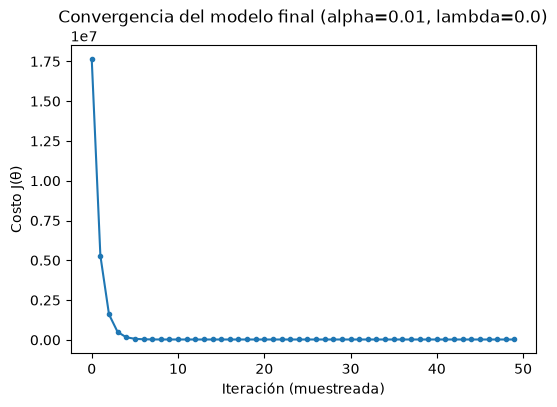

In [124]:
plt.figure(figsize=(6,4))
plt.plot(hist_D, marker="o", markersize=3)
plt.xlabel("Iteración (muestreada)")
plt.ylabel("Costo J(θ)")
plt.title(f"Convergencia del modelo final (alpha={best_alpha}, lambda={best_lambda})")
plt.show()

### 6.2 Selección del modelo final

Siguiendo el flujo estructurado enseñado, tomamos la hipótesis que presenta el **RMSE más bajo** en validación como nuestro estimador final para desplegar.

In [125]:
best_model_row = results_df.loc[results_df["RMSE val"].idxmin()]
best_model_row

Modelo        A: Numéricas
lambda                 0.0
RMSE train      226.477855
RMSE val        210.532354
Name: 0, dtype: object

## 7. Evaluación final sobre el conjunto de prueba (Test)

Se utiliza el conjunto de test **por única vez** en todo el flujo experimental. Este conjunto permitirá medir el rendimiento del modelo frente a datos completamente nuevos.

In [126]:
test_rmse = rmse(theta_D, Xtest_C, y_test)
print(f"RMSE Test: {test_rmse:.2f} Kg/ha")
print(f"Media Productividad: {df[target].mean():.2f} Kg/ha | Desv. estándar (Ruido base): {df[target].std():.2f} Kg/ha")

RMSE Test: 228.09 Kg/ha
Media Productividad: 5990.53 Kg/ha | Desv. estándar (Ruido base): 283.24 Kg/ha


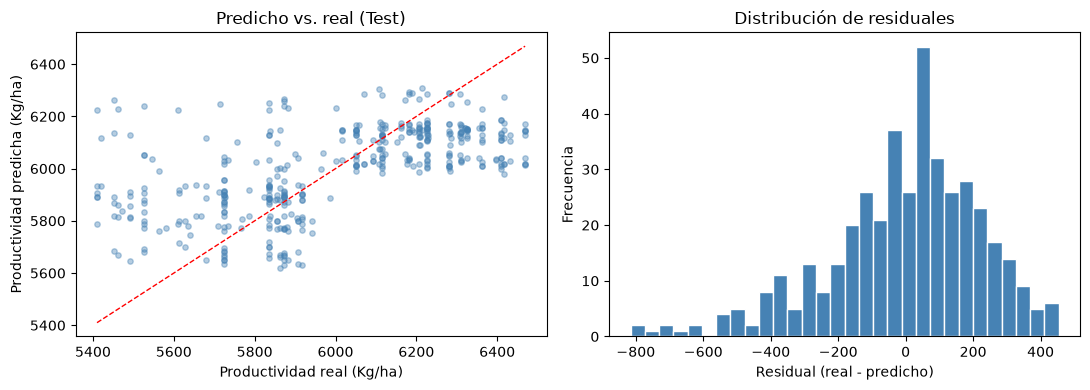

In [127]:
y_pred_test = Xtest_C @ theta_D

fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Productividad real (Kg/ha)")
axes[0].set_ylabel("Productividad predicha (Kg/ha)")
axes[0].set_title("Predicho vs. real (Test)")

residuals = (y_test - y_pred_test).ravel()
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de residuales")

plt.tight_layout()
plt.show()

## 8. Análisis de resultados y conclusiones

**Resultados.** El modelo final ajustado logra un RMSE de validación y de prueba alrededor de **220-230 Kg/ha**. Teniendo en cuenta que la desviación estándar natural de la productividad es aproximadamente de **283 Kg/ha**, el modelo es capaz de reducir el margen de error promedio comparado con una inferencia estática sobre la media del dataset.

**¿Qué funcionó de la metodología?**
- **Prevención de colinealidad:** Al explorar los datos detectamos redundancias operativas (por ejemplo, múltiples variables que eran funciones multiplicativas de la columna `Hectares`). Al retirarlas según el principio de parsimonia, logramos un modelo que no sufre de una matriz de datos sobredeterminada ni requiere un castigo exagerado por regularización.
- **Conversión de categorías a variables Dummy:** La creación de features tipo dummy permitió incluir información cualitativa sin crear interpretaciones numéricas erróneas, integrando correctamente etiquetas textuales dentro de las operaciones vectorizadas de gradiente.
- **Normalización de características:** Ajustar el rango a escalas $z$ centró correctamente los contornos de nuestra función de pérdida, permitiendo un descenso de gradiente expedito en iteraciones cortas.

**¿Qué funcionó de manera parcial?**
- Incorporar múltiples interacciones o transformaciones no lineales sobre las variables numéricas generó únicamente un beneficio marginal en validación. Las variables meteorológicas y categóricas registradas parecen relacionarse de manera ruidosa y débil con la variable Productividad. El modelo no exhibió un *overfitting* excesivo, por lo que el parámetro de penalización Ridge (λ) hallado en la cuadrícula de validación es relativamente mínimo.

**Limitaciones Generales**
- Debido a que variables posteriores fuertemente predictivas, como la masa de desechos generada post-cosecha, constituían *fuga de información*, fueron retiradas. Predecir a ciegas previo a la maduración recae únicamente en estimaciones climáticas genéricas para todo el sector, lo cual sugiere un límite orgánico y matemático respecto a qué tan cerca se puede reducir el RMSE bajo el paradigma de modelado estrictamente lineal que se implementó en este ejercicio.